### Workflow analysis

In this interactive notebook, we calculate the linear fit (slope and intercept) and performance metrics (coefficient of determination (R2), RMSE, MAE) for the overall benchmark and the individual substructures within it, including a subset of drug-like compounds. Additionally, we perform cross validation on the corrected model and generate confusion matrices to demonstrate the class assignment accuracy of the workflow (raw and adjusted).

#### Imports

In [17]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, accuracy_score, ConfusionMatrixDisplay
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

#### Overall benchmark

In this section, we calculate the linear fit (slope and intercept) and performance metrics (coefficient of determination (R2), RMSE, MAE) for the overall benchmark and the individual substructures within it. We also perform cross validation on the corrected model; in this model, raw computed barriers are corrected by applying the overall linear fit of the workflow prior to class assignment.

In [18]:
# Load the .csv file as a dataframe
results = pd.read_csv('literature_benchmark.csv')

In [19]:
# Coalesce substructures
results['Substructure'] = results['Substructure'].replace(
    {
     'Biaryl (5-5)': 'Biaryl',
     'Biaryl (6-6)': 'Biaryl', 
     'Biaryl (6-5)': 'Biaryl',
     'Biaryl (7-6)': 'Biaryl',
     'Diaryl amine': 'Diaryl',
     'Diaryl ether': 'Diaryl',
     'Diaryl thioether': 'Diaryl',
     'Diaryl sulfone': 'Diaryl',
     'Diaryl sulfoxide': 'Diaryl',
     'Benzamide (5)': 'Benzamide',
     'Benzamide (6)': 'Benzamide',
     'Benzthioamide': 'Benzamide',
     'Reverse benzamide (6)': 'Reverse benzamide',
     'Reverse thiobenzamide': 'Reverse benzamide',
     'Aryl-aliphatic (6-6)': 'Aryl-aliphatic',
     'Aryl-aliphatic (6-5)': 'Aryl-aliphatic',
     }
    )

# Remove entries where the literature barrier is non-exact
results = results[pd.to_numeric(results['Literature barrier (kcal/mol)'], errors='coerce').notnull()]

# Convert barrier columns to floats
results['Literature barrier (kcal/mol)'] = results['Literature barrier (kcal/mol)'].astype(float)
results['Computed barrier (kcal/mol)'] = results['Computed barrier (kcal/mol)'].astype(float)

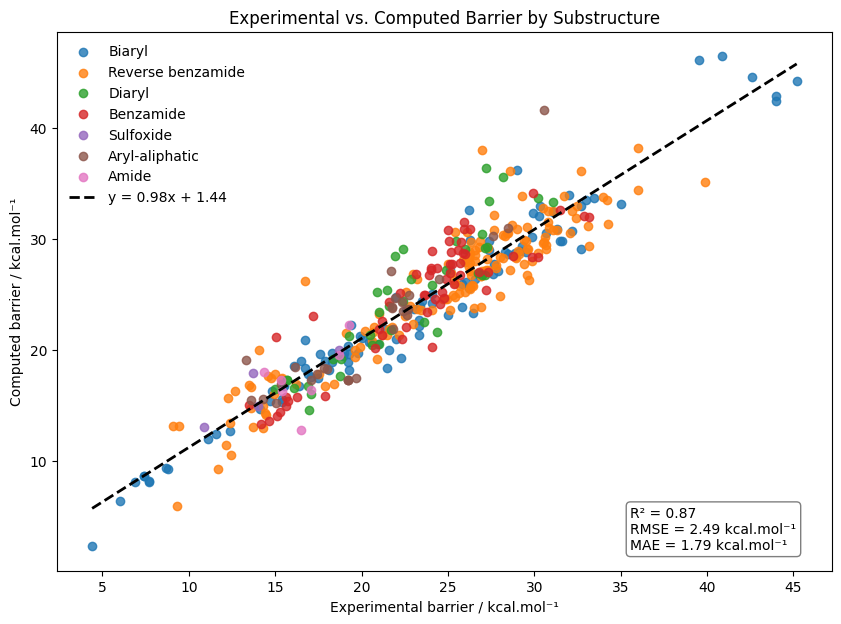

,N,Slope,Intercept,Raw R2,Raw RMSE,Raw MAE,Train R2,Train RMSE,Train MAE,Test R2,Test RMSE,Test MAE
Biaryl,107.0,1.00,0.66,0.95,1.91,1.34,NaN,NaN,NaN,NaN,NaN,NaN
Reverse benzamide,153.0,0.92,2.73,0.85,2.39,1.70,NaN,NaN,NaN,NaN,NaN,NaN
Diaryl,40.0,1.24,-3.38,0.68,3.29,2.47,NaN,NaN,NaN,NaN,NaN,NaN
Benzamide,61.0,1.04,0.45,0.75,2.71,2.12,NaN,NaN,NaN,NaN,NaN,NaN
Sulfoxide,4.0,0.85,4.29,0.12,2.51,2.17,NaN,NaN,NaN,NaN,NaN,NaN
Aryl-aliphatic,28.0,1.23,-3.08,0.72,3.05,2.15,NaN,NaN,NaN,NaN,NaN,NaN
Amide,7.0,0.87,3.11,0.18,2.45,2.12,NaN,NaN,NaN,NaN,NaN,NaN
Overall,400.0,0.98,1.44,0.87,2.49,1.79,0.89,2.27,1.71,0.89,2.28,1.71


In [20]:
# Initialize dictionary to store metrics
stats = {}

# Initialize the matplotlib figure
fig, ax = plt.subplots(figsize=(10, 7))

# Define colors for different substructures
colors = plt.cm.tab10(np.arange(10))

# Define different substructures types
substructures = results['Substructure'].unique()

# Iterate over each substructure
for i, substructure in enumerate(substructures):

    # Get the data for the substructure
    sub_df = results[results['Substructure'] == substructure]

    # Define x and y
    X = np.array(sub_df['Literature barrier (kcal/mol)'])
    y = np.array(sub_df['Computed barrier (kcal/mol)'])

    # Calculate raw metrics
    raw_r2 = r2_score(y, X)
    raw_rmse = root_mean_squared_error(y, X)
    raw_mae = mean_absolute_error(y, X)

    # Fit linear regression model
    model = LinearRegression()
    model.fit(X.reshape(-1, 1), y)

    # Get the slope and intercept of model
    m = model.coef_[0]
    b = model.intercept_

    # Save stats
    stats[substructure] = {
        "N": len(X),
        "Slope": m,
        "Intercept": b,
        "Raw R2": raw_r2,
        "Raw RMSE": raw_rmse,
        "Raw MAE": raw_mae,
    }

    # Plot the scatter points
    ax.scatter(X, y, label=substructure, color=colors[i % len(colors)], alpha=0.8)

# Get x and y for the overall dataset
X = results['Literature barrier (kcal/mol)'].values
y = results['Computed barrier (kcal/mol)'].values

# Calculate raw metrics
raw_r2 = r2_score(y, X)
raw_rmse = root_mean_squared_error(y, X)
raw_mae = mean_absolute_error(y, X)

# Fit linear regression model
model = LinearRegression()
model.fit(X.reshape(-1, 1), y)

# Get the slope and intercept of model
m = model.coef_[0]
b = model.intercept_

# Get predicted values
y_pred = model.predict(X.reshape(-1, 1))

# Initialize 5-fold cross validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize lists to hold CV metrics
train_r2_scores = []
train_rmse_scores = []
train_mae_scores = []
test_r2_scores = []
test_rmse_scores = []
test_mae_scores = []

# Iterate over CV splits
for train_index, test_index in kf.split(X):

    # Split X and y into train and test sets
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit linear regression model
    model = LinearRegression()
    model.fit(X_train.reshape(-1, 1), y_train)

    # Make predictions on train set
    y_pred_train = model.predict(X_train.reshape(-1, 1))

    # Calculate training metrics
    train_r2 = r2_score(y_train, y_pred_train)
    train_rmse = root_mean_squared_error(y_train, y_pred_train)
    train_mae = mean_absolute_error(y_train, y_pred_train)
    
    # Make predictions on test set
    y_pred_test = model.predict(X_test.reshape(-1, 1))
    
    # Calculate test metrics
    test_r2 = r2_score(y_test, y_pred_test)
    test_rmse = root_mean_squared_error(y_test, y_pred_test)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    
    # Record CV metrics
    train_r2_scores.append(train_r2)
    train_rmse_scores.append(train_rmse)
    train_mae_scores.append(train_mae)
    test_r2_scores.append(test_r2)
    test_rmse_scores.append(test_rmse)
    test_mae_scores.append(test_mae)

# Average CV scores
train_r2 = np.mean(train_r2_scores)
train_rmse = np.mean(train_rmse_scores)
train_mae = np.mean(train_mae_scores)
test_r2 = np.mean(test_r2_scores)
test_rmse = np.mean(test_rmse_scores)
test_mae = np.mean(test_mae_scores)

# Save stats
stats["Overall"] = {
    "N": len(X),
    "Slope": m,
    "Intercept": b,
    "Raw R2": raw_r2,
    "Raw RMSE": raw_rmse,
    "Raw MAE": raw_mae,
    "Train R2": train_r2,
    "Train RMSE": train_rmse,
    "Train MAE": train_mae,
    "Test R2": test_r2,
    "Test RMSE": test_rmse,
    "Test MAE": test_mae,
}

# Plot overall line of best fit
ax.plot(np.sort(X), y_pred[np.argsort(X)], color='black', linewidth=2, linestyle='--', label=f'y = {m:.2f}x + {b:.2f}')

# Set layout
ax.set_title("Experimental vs. Computed Barrier by Substructure")
ax.set_xlabel("Experimental barrier / kcal.mol⁻¹", fontsize=10)
ax.set_ylabel("Computed barrier / kcal.mol⁻¹", fontsize=10)
ax.legend(loc='best', frameon=False)

# Annotate metrics
ax.text(
    0.74, 0.12,
    f'R² = {raw_r2:.2f}\nRMSE = {raw_rmse:.2f} kcal.mol⁻¹\nMAE = {raw_mae:.2f} kcal.mol⁻¹', 
    transform=ax.transAxes, 
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.5)
)

# Show figure
plt.show()

# Show metrics
pd.DataFrame(stats).T.round(2)

#### Drug-like benchmark

In this section, we calculate the linear fit (slope and intercept) and performance metrics (coefficient of determination (R2), RMSE, MAE) for a subset of 20 drug-like compounds from the literature benchmark.

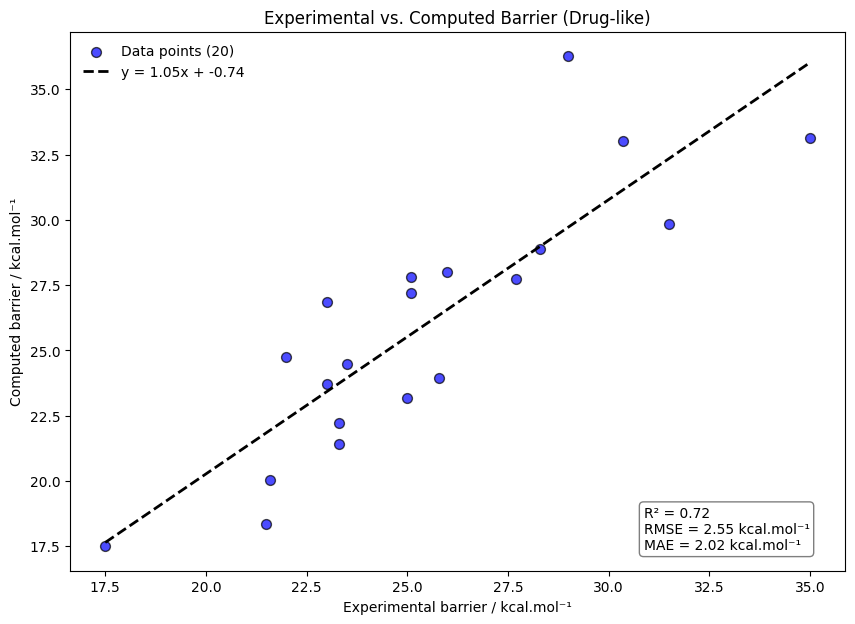

In [21]:
# Get drug-like reuslts
drug_results = results[results['Drug-like'] == True]

# Get x and y for the drug dataset
X_drug = drug_results['Literature barrier (kcal/mol)'].values
y_drug = drug_results['Computed barrier (kcal/mol)'].values

# Calculate raw metrics
raw_r2 = r2_score(y_drug, X_drug)
raw_rmse = root_mean_squared_error(y_drug, X_drug)
raw_mae = mean_absolute_error(y_drug, X_drug)

# Fit linear regression model
model = LinearRegression()
model.fit(X_drug.reshape(-1, 1), y_drug)

# Get the slope and intercept of model
m = model.coef_[0]
b = model.intercept_

# Get predicted values
y_pred = model.predict(X_drug.reshape(-1, 1))

# Initialize the matplotlib figure
fig, ax = plt.subplots(figsize=(10, 7))

# Plot scatter data and line of best fit
ax.scatter(X_drug, y_drug, color='blue', s=50, alpha=0.7, edgecolors='k', label=f'Data points ({len(y_drug)})')
ax.plot(np.sort(X_drug), y_pred[np.argsort(X_drug)], color='black', linewidth=2, linestyle='--', label=f'y = {m:.2f}x + {b:.2f}')

# Set layout
ax.set_title("Experimental vs. Computed Barrier (Drug-like)")
ax.set_xlabel("Experimental barrier / kcal.mol⁻¹", fontsize=10)
ax.set_ylabel("Computed barrier / kcal.mol⁻¹", fontsize=10)
ax.legend(loc='best', frameon=False)

# Annotate metrics
ax.text(
    0.74, 0.12,
     f'R² = {raw_r2:.2f}\nRMSE = {raw_rmse:.2f} kcal.mol⁻¹\nMAE = {raw_mae:.2f} kcal.mol⁻¹', 
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.5)
)

# Show figure
plt.show()

#### Class assignment accuracy

In this section, we generate confusion matrices to demonstrate the raw class assignment accuracy of the workflow. We repeat this analysis with a margin of error (equal to the raw RMSE of the literature benchmark) applied to the class boundaries.

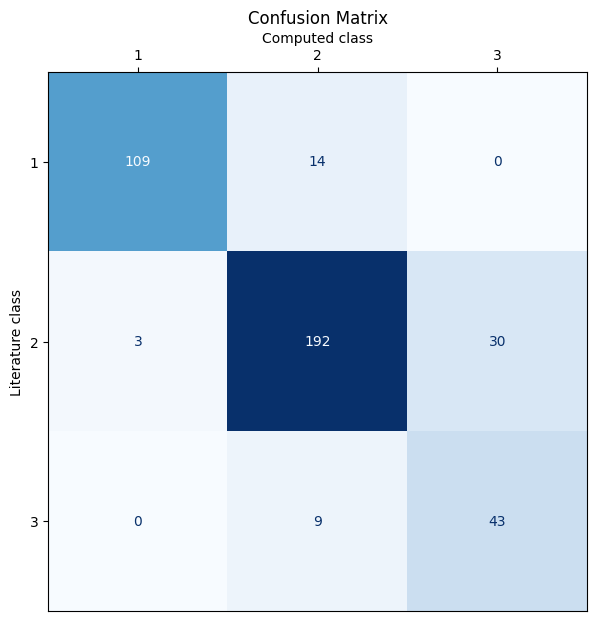

Overall accuracy: 86.0 %
Number of misclassified compounds: 56 / 400


In [22]:
# Define data
y_true = results['Literature class']
y_pred = results['Computed class']

# Calculate overall accuracy
accuracy = accuracy_score(y_true, y_pred)

# Get misclassified entries
misclassified = results[y_true != y_pred]

# Specify all label names
classes = np.unique(np.concatenate([y_true, y_pred]))

# Initialize the matplotlib figure
fig, ax = plt.subplots(figsize=(7, 7))

# Display the non-normalized confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=classes,
    cmap=plt.cm.Blues,
    normalize=None,
    colorbar=False,
    ax=ax,
)

# Set layout
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.set_xlabel("Computed class")
ax.set_ylabel("Literature class")
ax.set_title("Confusion Matrix")

# Show figure
plt.show()

# Report metrics
print(f"Overall accuracy: {100*accuracy:.1f} %")
print(f"Number of misclassified compounds: {len(misclassified)} / {len(results)}")

Apply a margin of error to the class boundaries:

In [23]:
# Iterate over the results dataframe
for idx, row in results.iterrows():
    index = row['Index']
    name = f"benchmark_{index}"
    smiles = row['SMILES']
    literature_class = row['Literature class']
    computed_class = row['Computed class']
    literature_barrier = row['Literature barrier (kcal/mol)']
    computed_barrier = row['Computed barrier (kcal/mol)']

    # Apply the raw RMSE to the class
    if computed_class < literature_class:
        updated_barrier = computed_barrier + stats["Overall"]["Raw RMSE"]
    elif computed_class > literature_class:
        updated_barrier = computed_barrier - stats["Overall"]["Raw RMSE"]
    else:
        updated_barrier = computed_barrier
    
    # Reassign the class with additional margin of error
    if computed_class != literature_class:
        new_class = 3 if updated_barrier > 30 else 1 if updated_barrier < 20 else 2
    else:
        new_class = computed_class

    # Update the results dataframe
    results.at[idx, 'Updated barrier'] = updated_barrier
    results.at[idx, 'Updated class'] = new_class

# Convert the class column to integers
results['Updated class'] = results['Updated class'].astype(int)

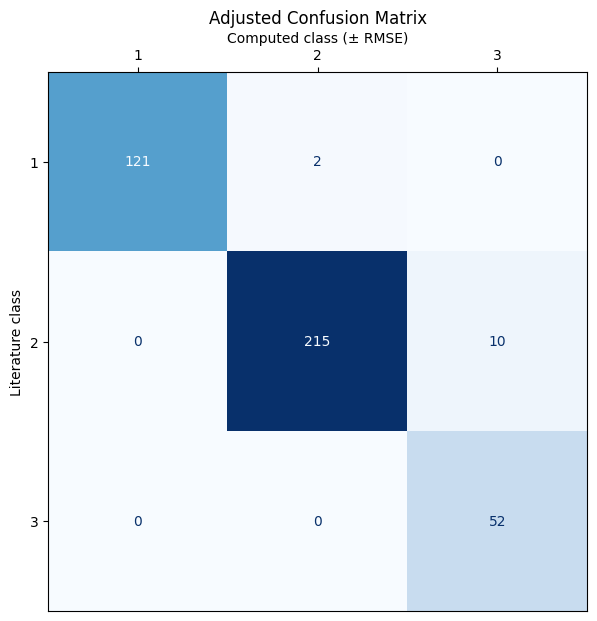

Overall accuracy: 97.0 %
Number of misclassified compounds: 12 / 400


In [24]:
# Define data
y_true = results['Literature class']
y_pred = results['Updated class']

# Calculate overall accuracy
accuracy = accuracy_score(y_true, y_pred)

# Get misclassified entries
misclassified = results[y_true != y_pred]

# Specify all label names
classes = np.unique(np.concatenate([y_true, y_pred]))

# Initialize the matplotlib figure
fig, ax = plt.subplots(figsize=(7, 7))

# Display the non-normalized confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=classes,
    cmap=plt.cm.Blues,
    normalize=None,
    colorbar=False,
    ax=ax,
)

# Set layout
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.set_xlabel("Computed class (± RMSE)")
ax.set_ylabel("Literature class")
ax.set_title("Adjusted Confusion Matrix")

# Show figure
plt.show()

# Report metrics
print(f"Overall accuracy: {100*accuracy:.1f} %")
print(f"Number of misclassified compounds: {len(misclassified)} / {len(results)}")